## Figure 2: Preliminary Integrative Analysis

### R Setup
To avoid reimplementing Python-based data import functions in R (and to ensure equivalent results across languages), we use the Python-based data import functions and convert the DataFrames to R.

In [1]:
# Load R magic for Jupyter cells
%load_ext rpy2.ipython

In [2]:
# Add Python repository to path
import sys
sys.path.append("../../src/python")

In [3]:
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from pilot.data_import import import_global, import_meta, import_phospho, import_rna

In [4]:
meta = import_meta()

# Load in datasets using Python-based functions and concatenate BeatAML 210
# and Pilot cohorts
global_prot = import_global()
global_prot = pd.concat(global_prot, axis=0)
phospho = import_phospho()
phospho = pd.concat(phospho, axis=0)
phospho.columns = phospho.columns.str.replace("-", ".")

rna = import_rna(return_symbols=True, batch_correct=True, tpm=False)
rna = pd.concat(rna, axis=0)
rna = rna.loc[rna.index.intersection(meta.index), :]

# Convert Python objects to R for use in later notebook cells
with localconverter(ro.default_converter + pandas2ri.converter):
    global_r = ro.conversion.py2rpy(global_prot)
    phospho_r = ro.conversion.py2rpy(phospho)
    rna_r = ro.conversion.py2rpy(rna)
    meta_r = ro.conversion.py2rpy(meta)

Welcome, JLChin!

[syn69692583:combinedBeatAML_pilotMetadata_20260317.csv]: Found existing file at /Users/jackson.chin/.synapseCache/115/169939115/combinedBeatAML_pilotMetadata_20260317.csv, skipping download.
[syn64126463:beataml_waves1to4_sample_mapping.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/872/150013872/beataml_waves1to4_sample_mapping.xlsx, skipping download.
[syn64126458:1-s2.0-S1535610822003129-mmc2.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/845/150013845/1-s2.0-S1535610822003129-mmc2.xlsx, skipping download.
Welcome, JLChin!

Welcome, JLChin!

Welcome, JLChin!

[syn64126462:beataml_waves1to4_counts_dbgap.txt]: Found existing file at /Users/jackson.chin/.synapseCache/867/150013867/beataml_waves1to4_counts_dbgap.txt, skipping download.
[syn68820229:RNAseq expression data.txt]: Found existing file at /Users/jackson.chin/.synapseCache/317/160991317/RNAseq expression data.txt, skipping download.
[syn68820228:PilotYR_1_2_metadata_083024_w

### Subfigure 2a: Kinase Enrichment Analysis
With the phosphoproteomic measurements, a major question is if differential expression across phosphosites reflects differences in upstream kinase activity. Such kinase behavior may be inferred from phosphoproteomic measurements via Kinase-Substrate Enrichment Analysis (KSEA).


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    Welcome, JLChin!

[syn73849653:psp_2023_ks_data.csv]: Found existing file at /Users/jackson.chin/.synapseCache/867/169440867/psp_2023_ks_data.csv, skipping download.



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Loading required package: ggplot2
Loading required package: ggrepel
here() starts at /Users/jackson.chin/amlMultidrugResistance/aml_outcome_disparities

New synapser version detected:
    You are using synapser version 2.0.0.200.
    synapser version 2.1.5.356 is detected at http://ran.synapse.org.
    To upgrade to the latest version of synapser, please run the following command:
    install.packages("synapser", repos="http://ran.synapse.org")


TERMS OF USE NOTICE:
  When using Synapse, remember that the terms and conditions of use require that you:
  1) Attribute data contributors when discussing these data or results from these data.
  2) Not discriminate, identify, or recontact individuals or groups represented by the data.
  3) Use and contribute only data de-identified to HIPAA standa

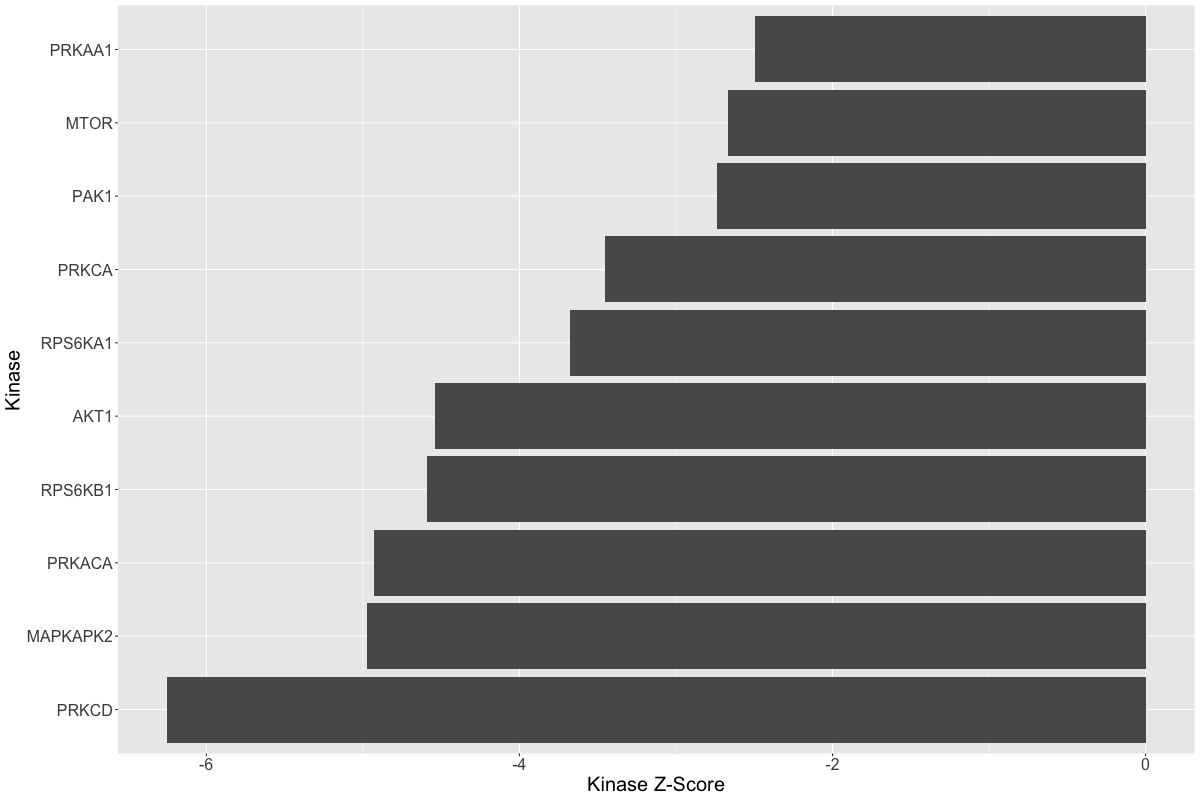

In [5]:
%%R -w 1200 -h 800 -u px -i phospho_r -i meta_r
source("../../src/r/proteomics/run_ksea.R")
ksea_res <- run_ksea(phospho_r, meta_r)
ksea_table <- ksea_res$table
write.csv(ksea_res$table, "ksea_results.csv", row.names = FALSE)
write.csv(ksea_res$links, "../../src/python/data/Kinase-Substrate Links.csv", row.names = FALSE)
ksea_res$bar_chart

### Subfigure 2b: PRKACA Substrate Differential Expression
KSEA indicates that PRKACA is exhibiting reduced activity in Black AML patients. To validate, we can examine the differential expression of PRKACA substrates across Black and White patients and use MANOVA to compare mean expression across PRKACA substrates between Black and White patients.

Note that individual t-tests find none of these substrates are significantly differentially expressed across Black and White patients (when accounting for false discovery rate). Strong association via MANOVA, therefore, may indicate that the difference truly is at the kinase level.

Welcome, JLChin!

[syn69692583:combinedBeatAML_pilotMetadata_20260317.csv]: Found existing file at /Users/jackson.chin/.synapseCache/115/169939115/combinedBeatAML_pilotMetadata_20260317.csv, skipping download.
[syn64126463:beataml_waves1to4_sample_mapping.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/872/150013872/beataml_waves1to4_sample_mapping.xlsx, skipping download.
[syn64126458:1-s2.0-S1535610822003129-mmc2.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/845/150013845/1-s2.0-S1535610822003129-mmc2.xlsx, skipping download.


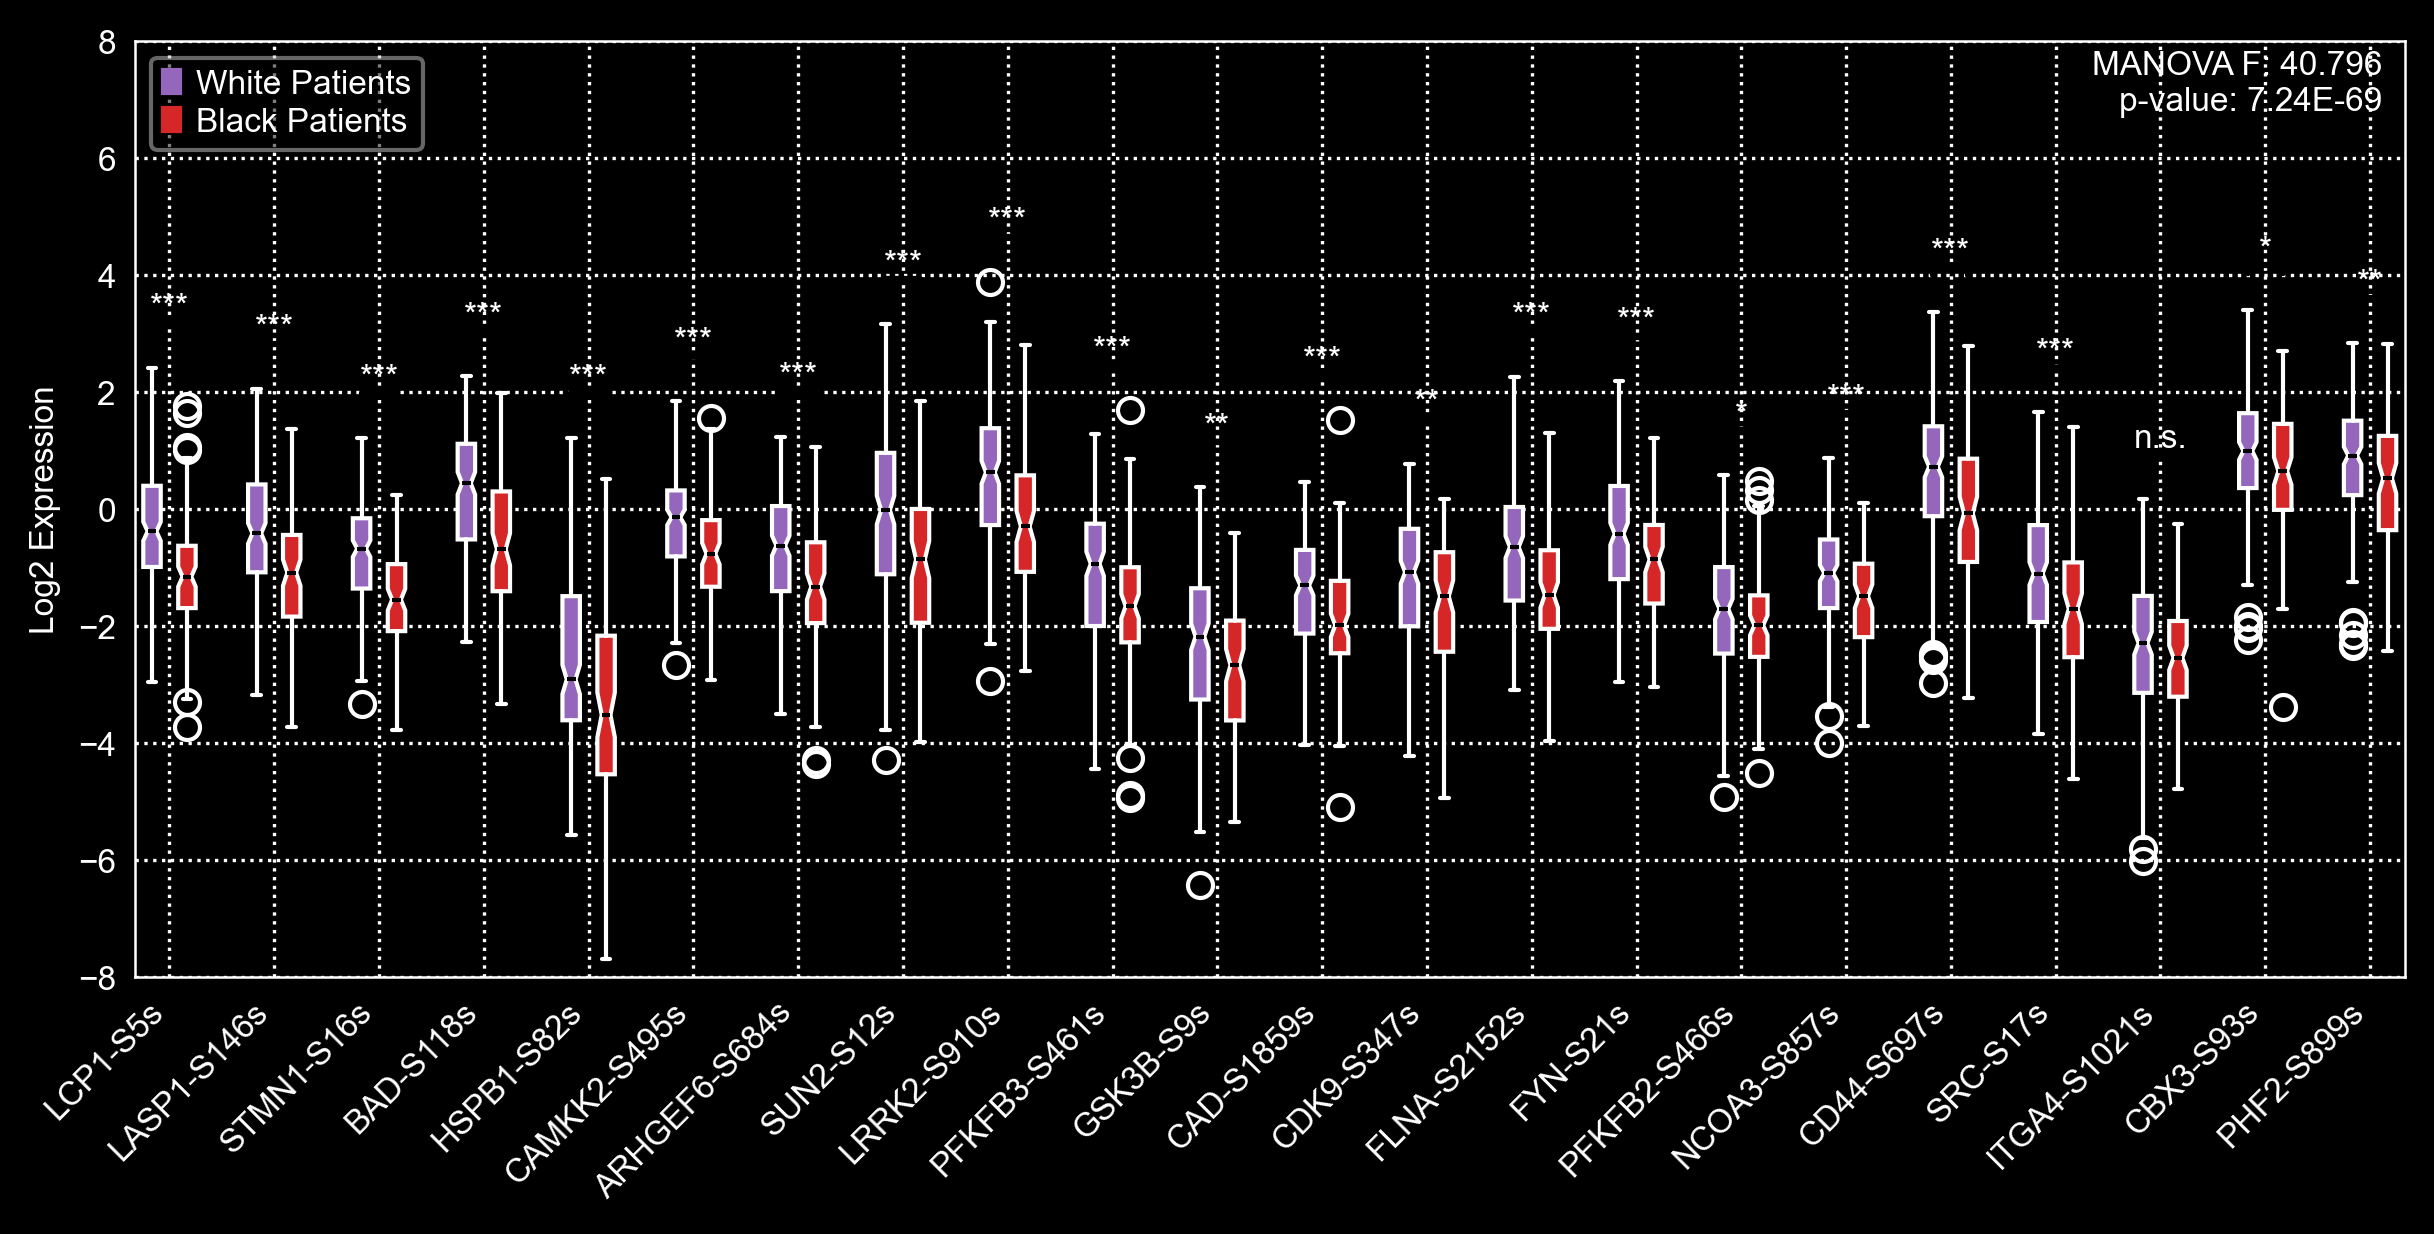

In [6]:
from figure2b import make_figure as make_figure_2b
fig_2b = make_figure_2b()

### Subfigure 2c: PRKACA Substrates & AML Subtypes
MANOVA provides further evidence that PRKACA substrates, and therefore PRKACA activity, are reduced in Black AML patients. To evaluate if these changes in phosphoproteomic expression associate with variation in AML manifestation, we examine the relationship between PRKACA substrate expression and (1) AML cell type scores derived via the scoring approach defined in [Bottomly et al](https://doi.org/10.1016/j.ccell.2022.07.002) and (2) Hematopoietic Aging Scores (HAS) from [Cheng et al](https://doi.org/10.1182/blood.2024027692).

An interesting aside is that the KSEA, cell type scores, and HAS all use different types of data (phosphoproteomic, transcriptomic, and global proteomic, respectively), indicating both that (1) integration of modalities provides a more comprehensive understanding of the underlying immunology and (2) that these conclusions are somewhat further reinforced as they are supported by multiple types of data.

Welcome, JLChin!

Welcome, JLChin!

[syn64126462:beataml_waves1to4_counts_dbgap.txt]: Found existing file at /Users/jackson.chin/.synapseCache/867/150013867/beataml_waves1to4_counts_dbgap.txt, skipping download.
[syn68820229:RNAseq expression data.txt]: Found existing file at /Users/jackson.chin/.synapseCache/317/160991317/RNAseq expression data.txt, skipping download.
[syn68820228:PilotYR_1_2_metadata_083024_withRNA DN.csv]: Found existing file at /Users/jackson.chin/.synapseCache/316/160991316/PilotYR_1_2_metadata_083024_withRNA DN.csv, skipping download.
[syn64126463:beataml_waves1to4_sample_mapping.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/872/150013872/beataml_waves1to4_sample_mapping.xlsx, skipping download.
Welcome, JLChin!



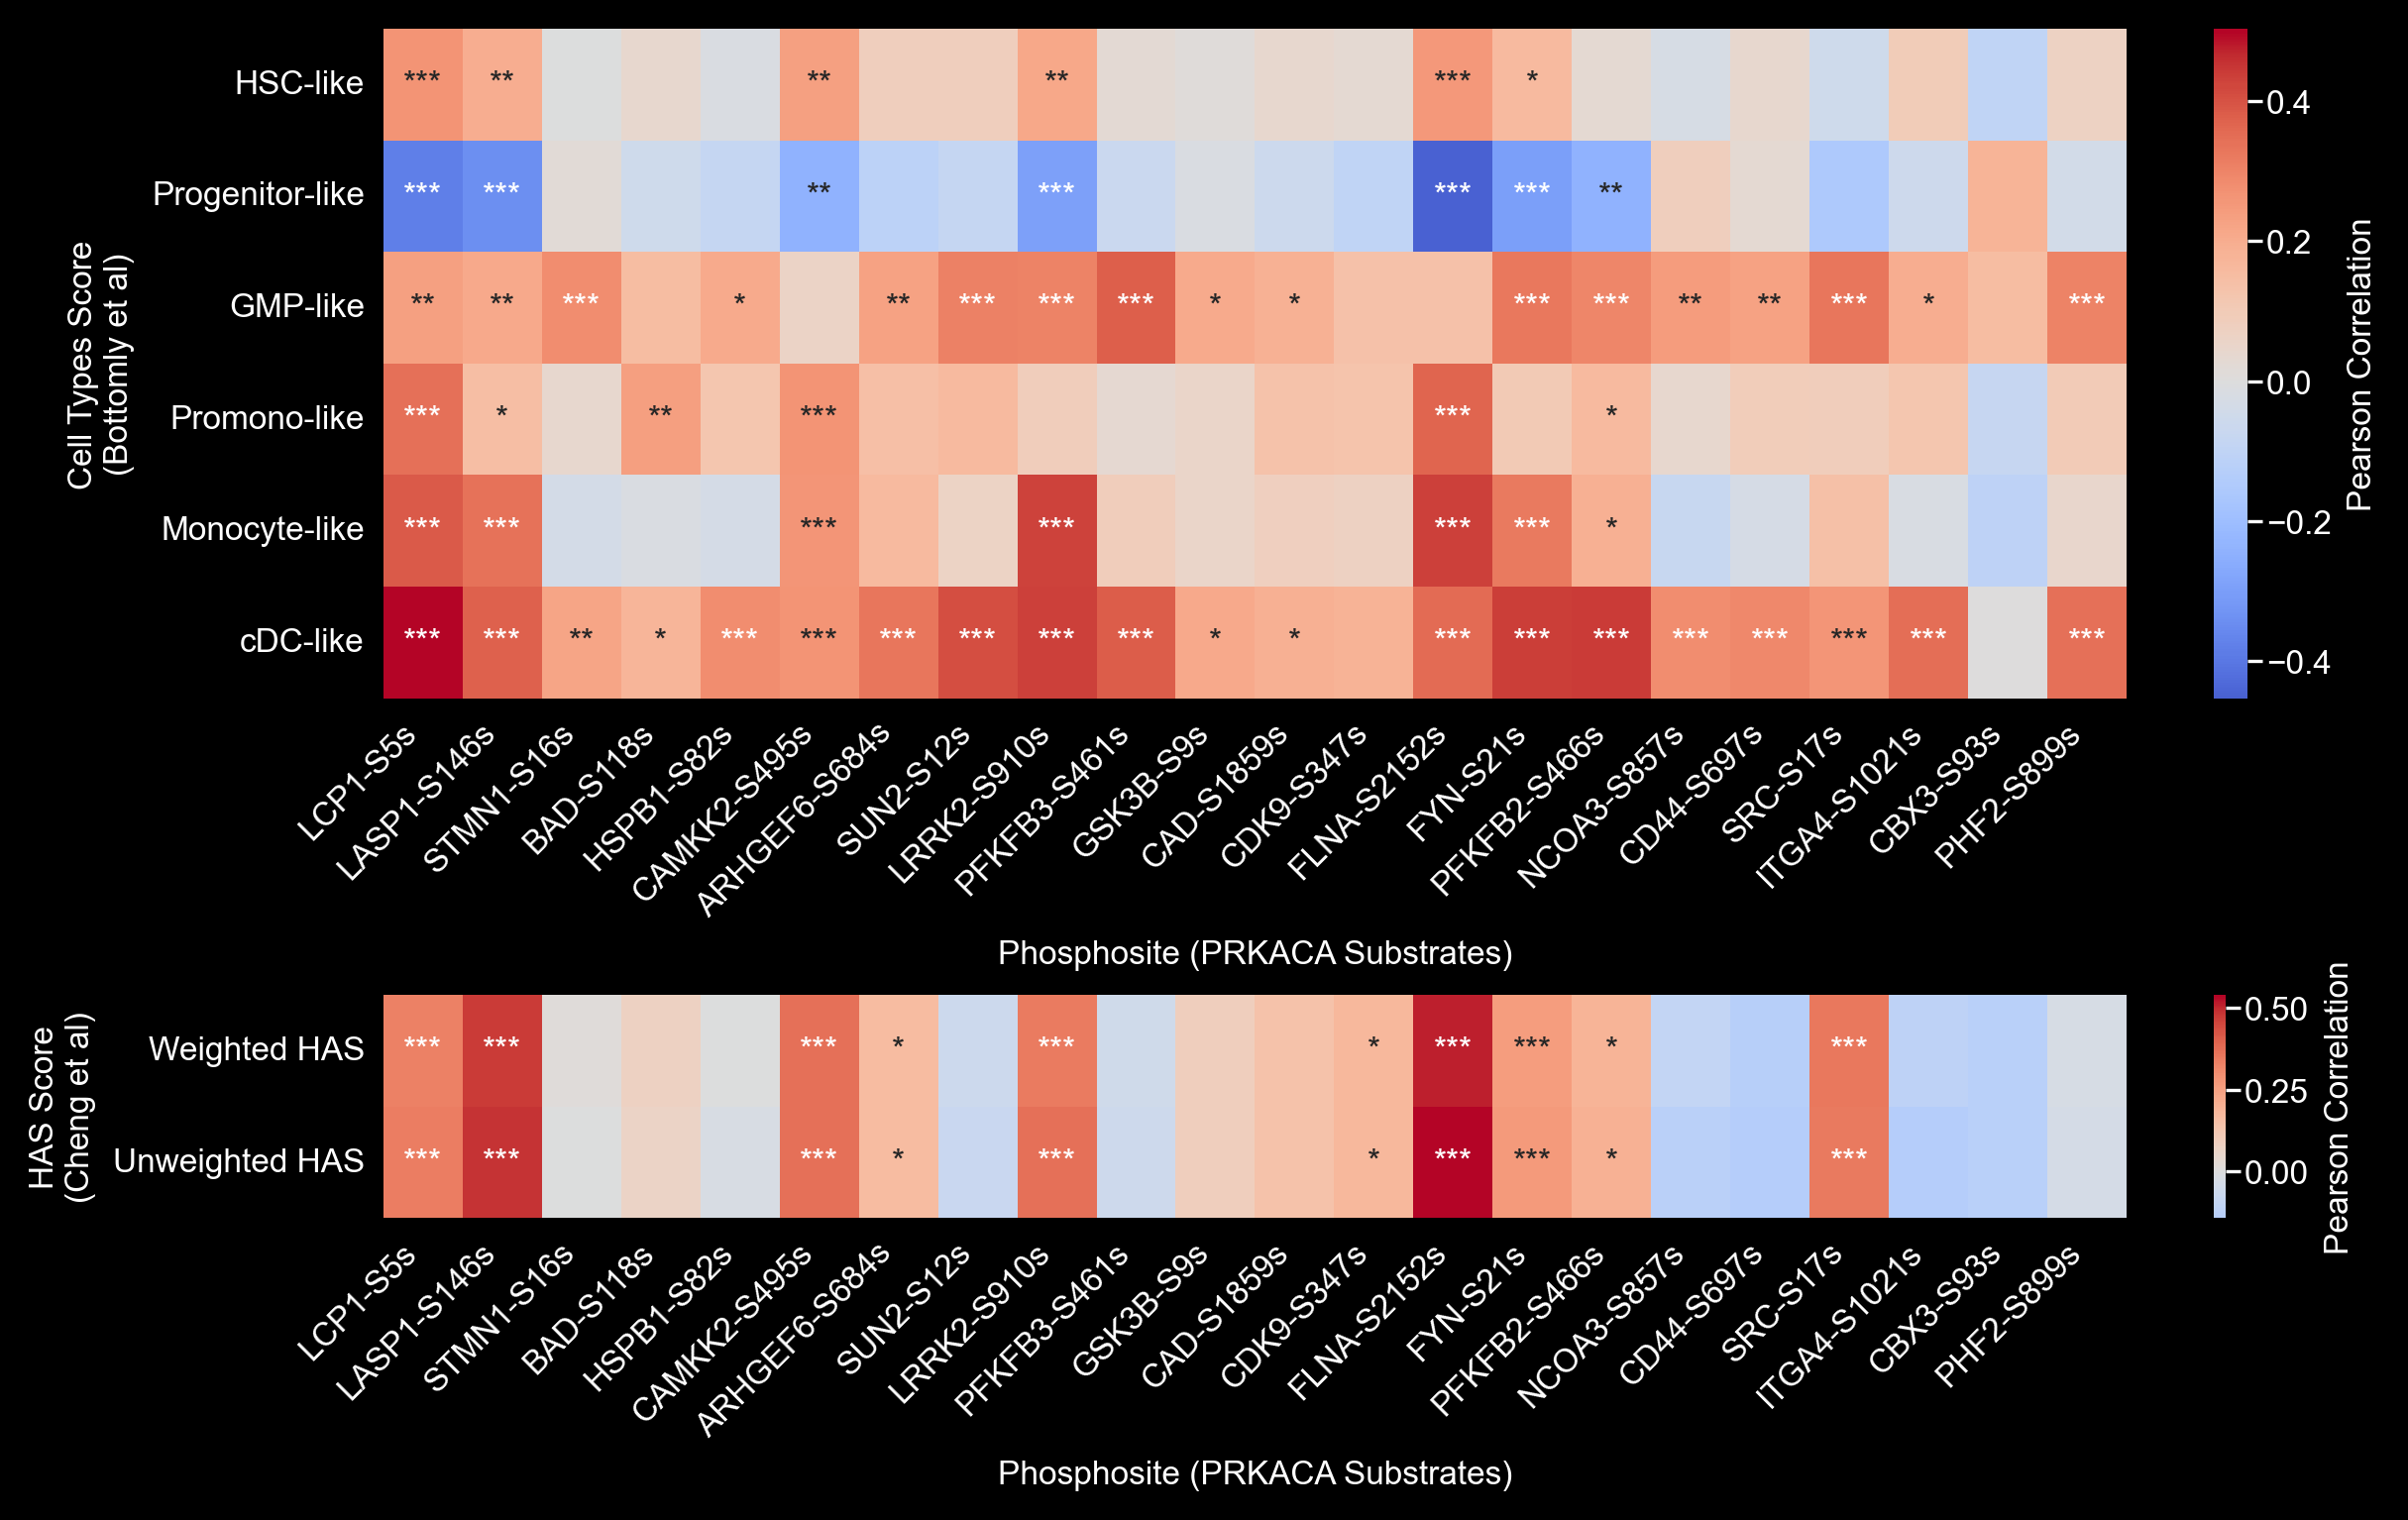

In [7]:
from figure2c import make_figure as make_figure_2c
fig_2c = make_figure_2c()

### Subfigure 2d: PRKACA Scores
Comparing PRKACA activity against other 'omes can be simplified by distilling PRKACA activity to a single score rather than evaluating correlations between numerous substrates and other 'omic measurements. This can be achieved by borrowing the approach from [Bottomly et al.](doi.org/10.1016/j.ccell.2022.07.002) to summarize expression across multiple genes into a cell type score--instead, we can run PCA on the expression of PRKACA substrates to create a PRKACA score that preserves race-based differences in PRKACA activity while summarizing kinase activity to a single value.

Welcome, JLChin!

Welcome, JLChin!

[syn69692583:combinedBeatAML_pilotMetadata_20260317.csv]: Found existing file at /Users/jackson.chin/.synapseCache/115/169939115/combinedBeatAML_pilotMetadata_20260317.csv, skipping download.
[syn64126463:beataml_waves1to4_sample_mapping.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/872/150013872/beataml_waves1to4_sample_mapping.xlsx, skipping download.
[syn64126458:1-s2.0-S1535610822003129-mmc2.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/845/150013845/1-s2.0-S1535610822003129-mmc2.xlsx, skipping download.


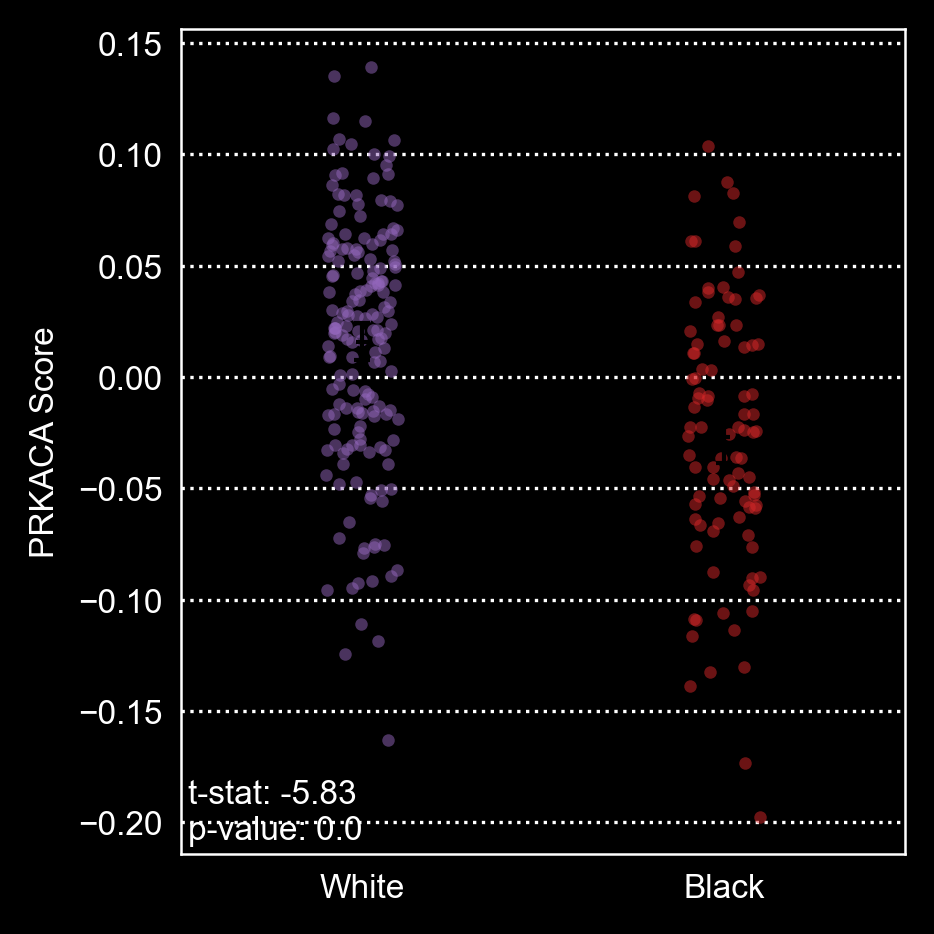

In [8]:
from figure2d import make_figure as make_figure_2d
fig_2d = make_figure_2d()

### Subfigure 2e: PRKACA, Lipidomics, and Metabolomics
With PRKACA activity summarized to a single score, we can now more efficiently evaluate the correlation between PRKACA activity and lipidomic/metabolomic measurements. Indeed, some lipids and metabolites exhibit significant correlations with PRKACA scores.

Welcome, JLChin!

Welcome, JLChin!

[syn71896311:rp_normalized_combat_edata_metab.csv]: Found existing file at /Users/jackson.chin/.synapseCache/125/166162125/rp_normalized_combat_edata_metab.csv, skipping download.
[syn25796769:PNNL_clinical_summary_03_03_2021.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/799/76897799/PNNL_clinical_summary_03_03_2021.xlsx, skipping download.
[syn68835814:PTRC_Exp26 Sample Key.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/432/161070432/PTRC_Exp26 Sample Key.xlsx, skipping download.
[syn71896667:normalized_combat_edata_lipid.csv]: Found existing file at /Users/jackson.chin/.synapseCache/248/166162248/normalized_combat_edata_lipid.csv, skipping download.


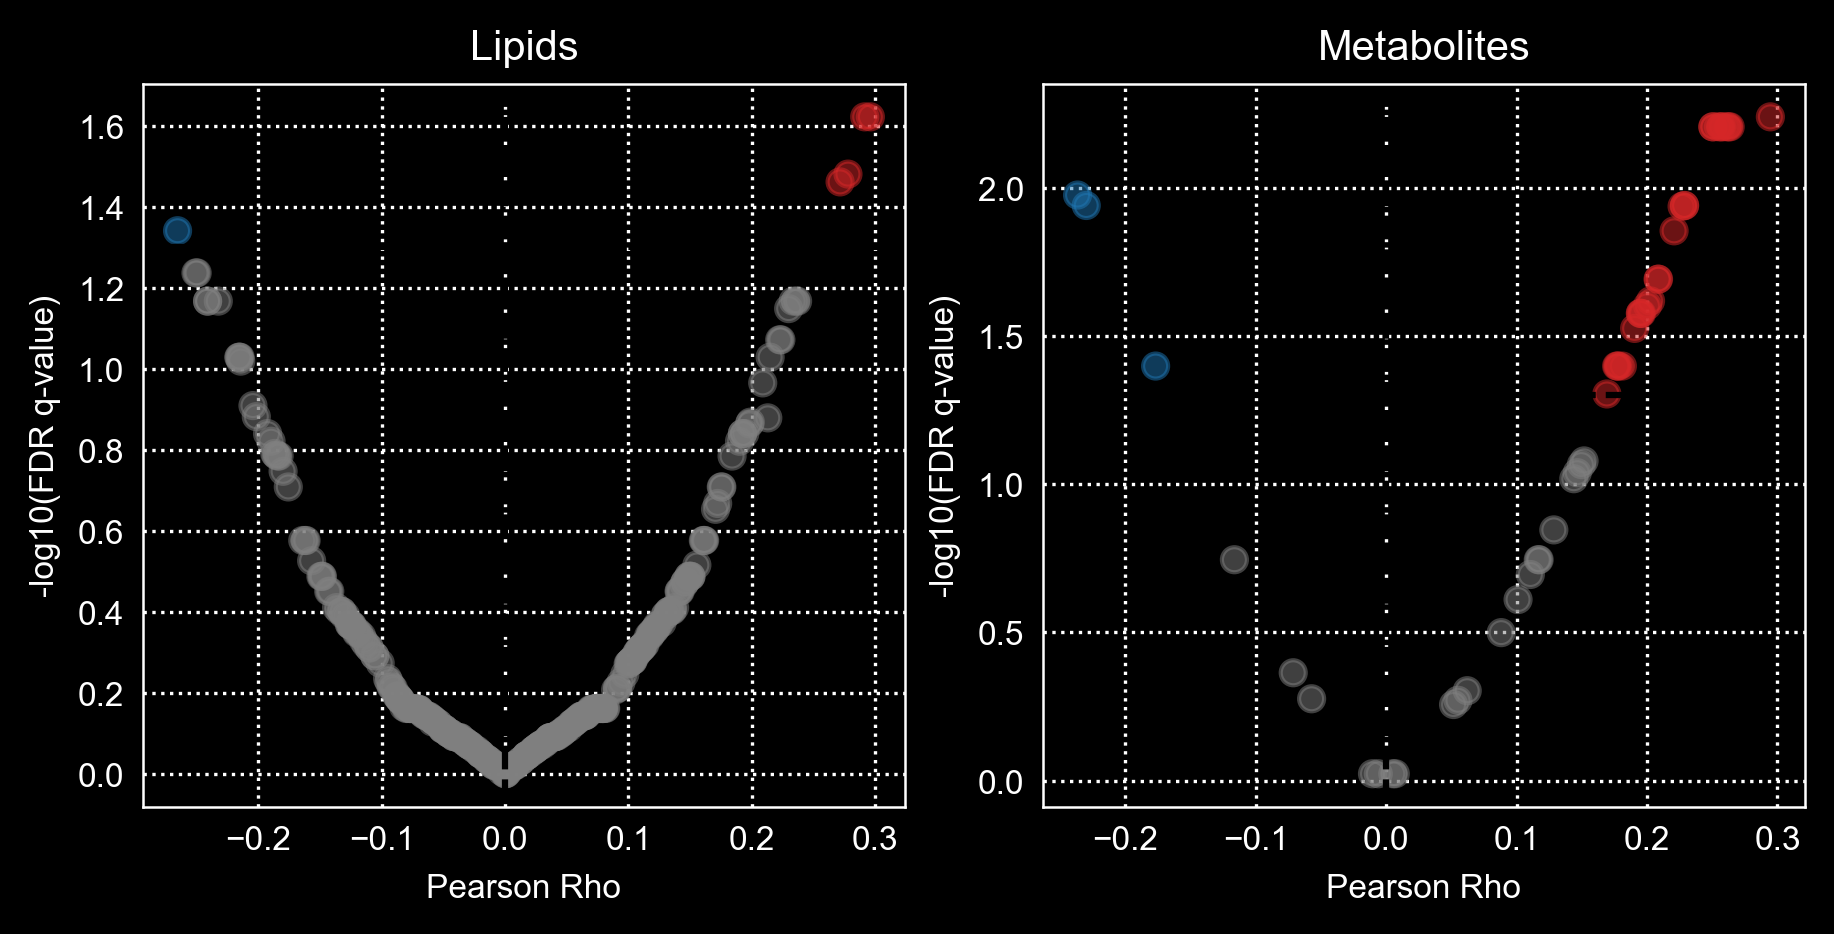

In [9]:
from figure2e import make_figure as make_figure_2e
fig_2e = make_figure_2e()

### Subfigure 2f: Metabolomic Interpretation
Lipid correlations are fairly easy to interpret, given that few are significantly correlated with PRKACA score and consist of Phosphatidylinositol variants. Metabolites, meanwhile, have substantially more metabolites correlated with PRKACA activity, though a large portion of those metabolites appear to be carnitine variants. A Fisher's Exact test can confirm whether carnitine variants are indeed enriched in the metabolites associated with PRKACA activity.

Welcome, JLChin!

Welcome, JLChin!

[syn71896311:rp_normalized_combat_edata_metab.csv]: Found existing file at /Users/jackson.chin/.synapseCache/125/166162125/rp_normalized_combat_edata_metab.csv, skipping download.
[syn25796769:PNNL_clinical_summary_03_03_2021.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/799/76897799/PNNL_clinical_summary_03_03_2021.xlsx, skipping download.
[syn68835814:PTRC_Exp26 Sample Key.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/432/161070432/PTRC_Exp26 Sample Key.xlsx, skipping download.


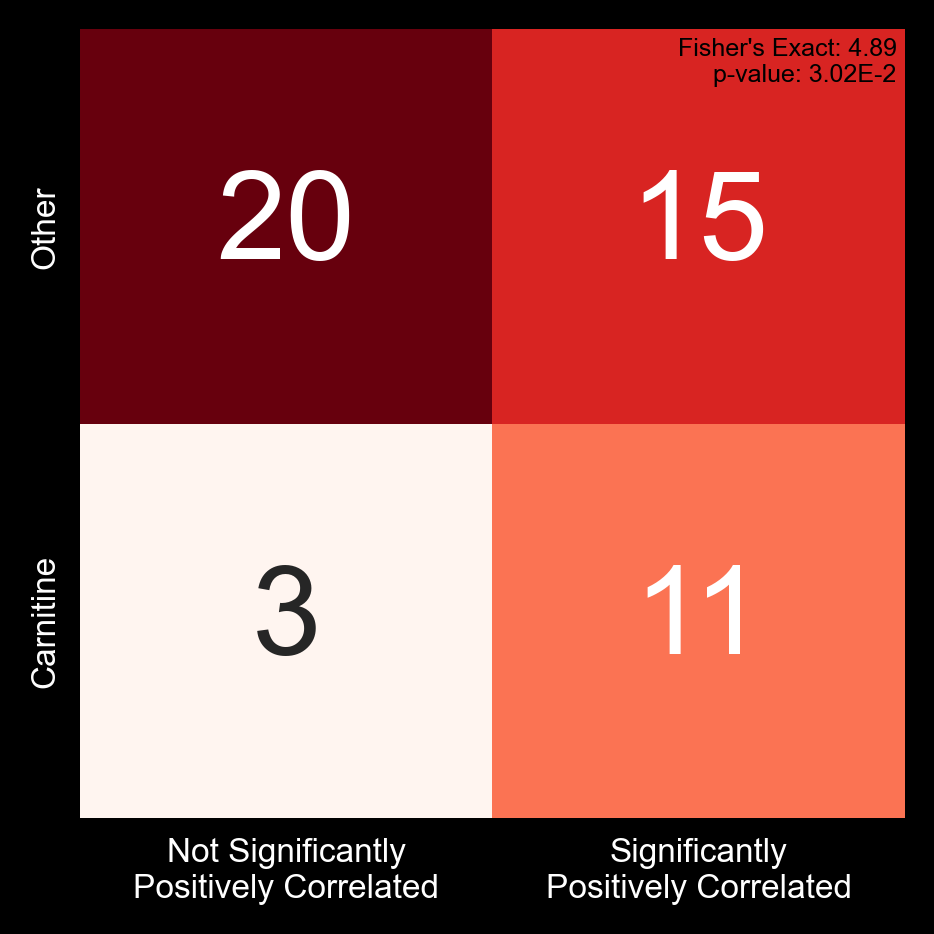

In [10]:
from figure2f import make_figure as make_figure_2f
fig_2f = make_figure_2f()

### Subfigure 2g: PRKACA enrichment
Finally, we can check how PRKACA activity associates with broader immune behaviors by evaluating its correlations with global proteomic and transcriptomic measurements. Below, we use Pearson correlation to pre-rank correlations between PRKACA activity and global/transcriptomic measurements for enrichment analyses. Indeed, it seems the transcriptomic measurements provide further support that PRKACA activity involves some dysregulation in metabolism via Oxidative Phosphorylation and Acetyl-CoA+ pathways.

In [11]:
from figure2g import make_figure as make_figure_2g
make_figure_2g()

Welcome, JLChin!

Welcome, JLChin!

[syn64126462:beataml_waves1to4_counts_dbgap.txt]: Found existing file at /Users/jackson.chin/.synapseCache/867/150013867/beataml_waves1to4_counts_dbgap.txt, skipping download.
[syn68820229:RNAseq expression data.txt]: Found existing file at /Users/jackson.chin/.synapseCache/317/160991317/RNAseq expression data.txt, skipping download.
[syn68820228:PilotYR_1_2_metadata_083024_withRNA DN.csv]: Found existing file at /Users/jackson.chin/.synapseCache/316/160991316/PilotYR_1_2_metadata_083024_withRNA DN.csv, skipping download.
[syn64126463:beataml_waves1to4_sample_mapping.xlsx]: Found existing file at /Users/jackson.chin/.synapseCache/872/150013872/beataml_waves1to4_sample_mapping.xlsx, skipping download.
Welcome, JLChin!



2026-03-19 14:00:42,582 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!
2026-03-19 14:00:50,669 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!
2026-03-19 14:00:51,425 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!
2026-03-19 14:01:18,651 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!


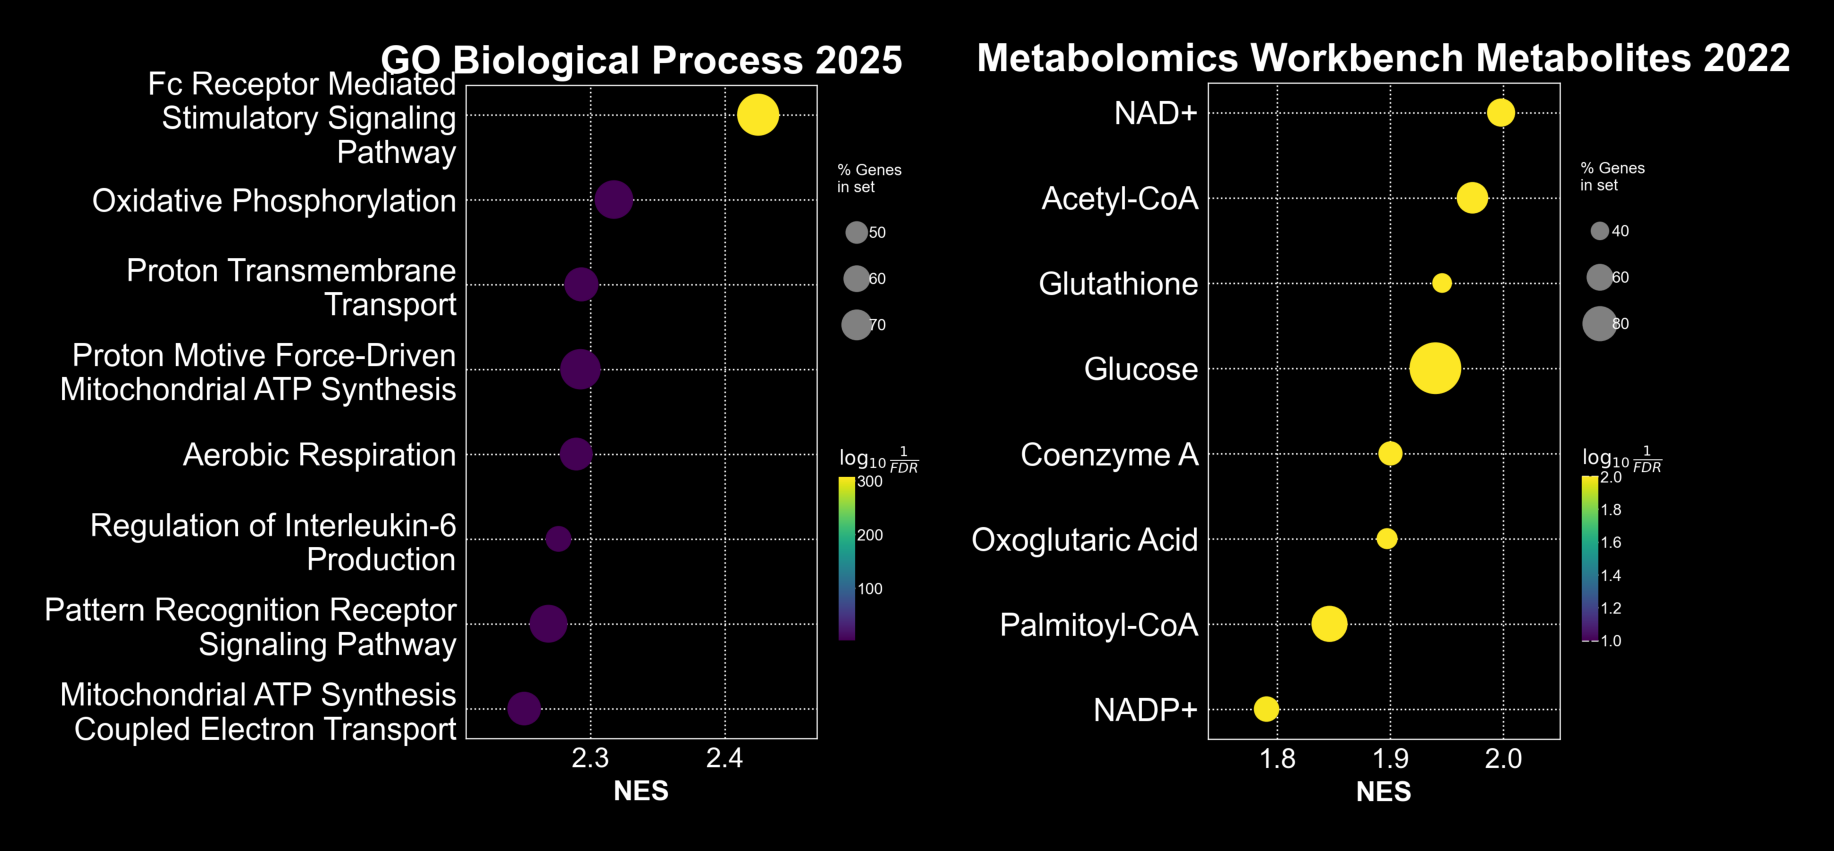

In [12]:
import matplotlib.pyplot as plt
from pilot.figures.figure_setup import get_setup

fig, axes = get_setup(
    1,
    2,
    fig_params={
        "figsize": (6, 3),
        "width_ratios": [1, 0.94]
    }
)

rna_go = plt.imread("enrichment/rna/GO_Biological_Process_2025_overexpressed.png")
rna_metab = plt.imread("enrichment/rna/Metabolomics_Workbench_Metabolites_2022_overexpressed.png")

axes[0].imshow(rna_go)
axes[1].imshow(rna_metab)

for ax in axes:
    ax.set_axis_off()